<div align="center" style="font-size:28px; font-weight:bold;">
MFE 409: Financial Risk Management
<br>Problem Set 1
<br>Valentin Haddad
<br>due 1/11/2026 before midnight
</div>

<br>

Students:
Lee James, Moazzami Ali, Yu Aiden, Cai Jenny, Li Zehao, Guo Lucy

## 1 VaR for an exponential distribution

#### 1. Assume an asset value in 10 days follows an exponential distribution with mean $W_0$. Derive a formula for the value-at-risk for confidence c and reference level $W_0$ for the asset. Apply with $W_0 = 70$ and $c = 99\%$.

#### Solution:

Let asset be denoted by variable $W$, where $W \sim Exp(\lambda)$ with mean $E[W] = W_0 = \frac{1}{\lambda}$ so $\lambda = \frac{1}{W_0}$

PDF of Exponential dist. is $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$ so to get CDF, we integrate the PDF from 0 to x:

$$
F(x) = \int_0^x f(x)dx = \int_0^x \lambda e^{-\lambda x} dx = -\frac{\lambda}{\lambda} e^{-\lambda x} |_0^x = -e^{-\lambda x} + 1 = 1 - e^{-\lambda x}
$$

so CDF is $F(x) = Prob(X \leq x) = 1 - e^{-\lambda x}$ for $x \geq 0$

From lecture for VaR, we have that $Prob(W \leq w) = 1 - c$ where $w = W_0 - VaR$. This is because we look at the left tail of the distribution since we are long and own the asset, so we lose money if price drops.

This means that the CDF of Exponential dist. is equal to $1 - c$ => as such $1 - e^{-\lambda w} = 1 - c$

Using $\lambda = \frac{1}{W_0}$ and $w = W_0 - VaR$, we can go ahead and derive the formula for VaR for confidence c and reference level $W_0$:

$$
\begin{aligned}
1 - e^{-\frac{1}{W_0}(W_0 - VaR)} &= 1 - c \\
e^{-1 + \frac{VaR}{W_0}} &= c \\
-1 + \frac{VaR}{W_0} &= \ln(c) \\
\frac{VaR}{W_0} &= 1 + \ln(c) \\
VaR &= W_0(1 + \ln(c))
\end{aligned}
$$

Given $W_0 = 70$ and $c = 99\%$, value for VaR is:

$$
VaR = 70(1 + ln(0.99)) = 69.2965
$$

$$
\boxed{VaR = 69.2965}
$$

#### 2. Now assume you are short this asset. Compute your value-at-risk for confidence c and apply with the same numerical values.

#### Solution:

Now because we short this asset, we don't have the asset anymore and we lose money if price goes up so we look at the right tail of the distribution.

This time we set the CDF of Exponential dist. equal to $c$ => as such $Prob(W \leq w) = 1 - e^{-\lambda w} = c$ and $w = W_0 + VaR$

Then we solve again for VaR:

$$
\begin{aligned}
1 - e^{-\frac{1}{W_0}(W_0 + VaR)} &= c \\
1 - e^{-1 - \frac{VaR}{W_0}} &= c \\
e^{-1 - \frac{VaR}{W_0}} &= 1 - c \\
-1 - \frac{VaR}{W_0} &= \ln(1 - c) \\
\frac{VaR}{W_0} &= -1 - \ln(1 - c) \\
VaR &= W_0(-1 - \ln(1 - c))
\end{aligned}
$$

Given $W_0 = 70$ and $c = 99\%$, value for VaR is:

$$
VaR = 70(-1 - ln(0.01)) = 252.362
$$

$$
\boxed{VaR = 252.362}
$$

#### 3. Comment on the similarity or difference between the results in the two questions.

#### Solution:

The similarity between the results is that both calculations use exponential distribution and same reference value ($W_0=70$) to find a threshold for the extreme 1% of outcomes. In both cases, we are solving for a quantile where the probability of exceeding the loss threshold matches the confidence level ($c=99\%$).

The difference between the results is that they differ significantly in magnitude because the exponential distribution is asymmetric. The long position's loss is capped at the asset's initial value (since prices cannot go below zero), resulting in a VaR of 69.30. In contrast, the short position faces theoretically unlimited risk due to the distribution's heavy, unbounded right tail (right-skewed), resulting in a much larger VaR of 252.36.

#### 4. Repeat the previous questions with expected shortfall.

#### Solution:

**- Long Position (left tail)**

PDF of Exponential dist. is $f(x) = \lambda e^{-\lambda x}$ for $x \geq 0$

From lecture for ES, we have that $ES = W_0 - E[W \mid W \le w]$ where $w = W_0 - VaR$. We also have $ES$ equal to:

$$
ES = W_0 - \frac{\int_0^w x f(x) dx}{\int_0^w f(x) dx}
$$

where denomintaor is just the CDF which we found equal to $1 - c$ for long position but need to integrate the numerator using integration by parts.

($\int_a^b u dv = uv \mid_a^b - \int_a^b v du$ where $u = x, du = dx, dv = \lambda e^{-\lambda x} dx, v = \int \lambda e^{-\lambda x} dx = -e^{-\lambda x}$)

$$
\begin{aligned}
\int_0^w x f(x) dx &= \int_0^w x \lambda e^{-\lambda x} dx \\
 &= -xe^{-\lambda x} \mid_0^w + \int_0^w e^{-\lambda x} dx \\
 &= -we^{-\lambda w} - \frac{1}{\lambda}e^{-\lambda x} \mid_0^w \\
 &= -we^{-\lambda w} - \frac{1}{\lambda}e^{-\lambda w} + \frac{1}{\lambda} \\
 &= -e^{-\lambda w}(w + \frac{1}{\lambda}) + \frac{1}{\lambda}
\end{aligned}
$$

So our $ES$ is now:

$$
ES = W_0 - \frac{-e^{-\lambda w}(w + \frac{1}{\lambda}) + \frac{1}{\lambda}}{1 - c}
$$

Plugging back $W_0 = \frac{1}{\lambda}$, $\lambda = \frac{1}{W_0}$, $w = W_0 - VaR$ into ES gives us:

$$
\begin{aligned}
ES &= W_0 + \frac{e^{-\frac{1}{W_0} (W_0 - VaR)}(W_0 - VaR + W_0) - W_0}{1 - c} \\
ES &= W_0 + \frac{e^{-1 + \frac{VaR}{W_0}}(2W_0 - VaR) - W_0}{1 - c} \\
ES &= W_0 + \frac{c(2W_0 - VaR) - W_0}{1 - c}
\end{aligned}
$$

Plugging values $W_0 = 70$, $c = 99\%$, and $VaR = 69.2965$, gives:
$$
ES = 70 + \frac{0.99(2*70 - 69.2965) - 70}{1 - 0.99} = 69.6465
$$

$$
\boxed{ES = 69.6465}
$$

<br>

**- Short Position (right tail)**

We have that $ES = E[W \mid W > w] - W_0$ where $w = W_0 + VaR$. We also have $ES$ equal to:

$$
ES = \frac{\int_w^∞ x f(x) dx}{\int_w^∞ f(x) dx} - W_0
$$

where the denomintaor is just $Prob(W > w) = 1 - c$ but need to integrate the numerator using integration by parts:

($\int_a^b u dv = uv \mid_a^b - \int_a^b v du$ where $u = x, du = dx, dv = \lambda e^{-\lambda x} dx, v = \int \lambda e^{-\lambda x} dx = -e^{-\lambda x}$)

$$
\begin{aligned}
\int_w^∞ x f(x) dx &= \int_w^∞ x \lambda e^{-\lambda x} dx \\
 &= -xe^{-\lambda x} \mid_w^\inf + \int_w^\inf e^{-\lambda x} dx \\
 &= we^{-\lambda w} - \frac{1}{\lambda}e^{-\lambda x} \mid_w^\inf \\
 &= we^{-\lambda w} + \frac{1}{\lambda}e^{-\lambda w} \\
 &= e^{-\lambda w}(w + \frac{1}{\lambda})
\end{aligned}
$$

So our $ES$ is now:

$$
ES = \frac{e^{-\lambda w}(w + \frac{1}{\lambda})}{1 - c} - W_0
$$

Plugging back $1 - c = e^{-\lambda w}$, $W_0 = \frac{1}{\lambda}$, and $w = W_0 + VaR$ into ES gives us:

$$
\begin{aligned}
ES &= \frac{e^{-\lambda w}(w + W_0)}{e^{-\lambda w}} - W_0 \\
ES &= W_0 + VaR + W_0 - W_0 \\
ES &= W_0 + VaR
\end{aligned}
$$

Plugging values $W_0 = 70$ and $VaR = 252.362$, gives:

$$
ES = 70 + 252.362 = 322.362
$$

$$
\boxed{ES = 322.362}
$$

## 2 VaR for mixtures

You have to allocate \$1bn in the stock market. You are discussing with your partner regarding the volatility of returns. She has a view that, in line with historical averages, the volatility of returns will be of $σ_1=12\%$ in the next year. However, you believe that volatility will be higher, in the orders of $σ_2=16\%$ for the next year. After discussing with your partner, you agree in the following way: stocks returns follow a normal distribution with mean $μ$ and $σ_1$ with probability $π$ and normal distribution with mean $μ$ and $σ_2$ with probability $1 - π$ . For now assume that $μ = 7\%$ and $π = 0.4$.

1. Compute the 1-year $99\%$ VaR with your view, with your partner view, and with the common view. Compare results and provide a very brief explanation as if you were presenting to your manager.

#### Solution:

**- My View:**

We have $\$1bn$, $μ = 7\%$, and $σ_2=16\%$ with cutoff $z(c)$

Since $c = 99\%$, then $z(c) = -2.326$

Now to find cutoff return (r), we can use the following and plug in corresponding values to find it:

$$
\begin{aligned}
r &= μ + σ_2 * z(c) \\
r &= 0.07 + 0.16 * -2.326 \\
r &= 0.07 -0.37216 \\
r &= -0.3022
\end{aligned}
$$

This means we lose 30.22% of \$1bn

99% 1-year VaR = $\$1bn * 0.3022 = \$302.2M$

<br>

**- My Partner's View:**

We have $\$1bn$, $μ = 7\%$, and $σ_1=12\%$ with cutoff $z(c)$

Since $c = 99\%$, then $z(c) = -2.326$

Now to find cutoff return (r), we can use the following and plug in corresponding values to find it:

$$
\begin{aligned}
r &= μ + σ_1 * z(c) \\
r &= 0.07 + 0.12 * -2.326 \\
r &= 0.07 - 0.27912 \\
r &= -0.2091
\end{aligned}
$$

This means we lose 20.91% of \$1bn

99% 1-year VaR = $\$1bn * 0.2091 = \$209.1M$

<br>

**- Common View:**

We have $μ = 7\%$, $σ_1=12\%$, $σ_2=16\%$, and $\pi = 0.4$

Mixture model includes $0.4$ or $40\%$ of my partner's distribution and $0.6$ or $60\%$ of my distribution, meaning the probability of model is a weighted average of two normal probabilities. Thus, we need to find a return $r_{mix}$ such that the combined probability of falling below it is 1%:

$$
P(R \le r_{mix}) = \pi * P(R_1 \le r_{mix}) + (1-\pi) * P(R_2 \le r_{mix}) = 0.01
$$

Substituting the Normal CDF ($\Phi$) for each corresponding probability gives:

$$
\pi * \Phi\left(\frac{r_{mix} - μ}{σ_1}\right) + (1 - \pi) * \Phi\left(\frac{r_{mix} - μ}{σ_2}\right) = 0.01
$$

Now we can plug in the values given and solve for $r_{mix}$:

$$
\begin{aligned}
0.4 * \Phi\left(\frac{r_{mix} - 0.07}{0.12}\right) + 0.6 * \Phi\left(\frac{r_{mix} - 0.07}{0.16}\right) &= 0.01 \\
r_{mix} &= -0.2758
\end{aligned}
$$

This means we lose approx. 27.58% of \$1bn. Also it makes sense to get a number between -20% and -30%

99% 1-year VaR = $\$1bn * 0.2758 = \$275.8M$

If we follow my view, there is going to be $\$302.2M$ risk. However, if we follow my partner's view, there is going to be $\$209.1M$ risk. And if we follow the common view, there is going to be approx. $\$275.8M$ risk. It's worth mentioning that the combined risk is not just a simple average of the two VaRs ($0.4 * 209.1 + 0.6 * 302.2 \approx 264.96$). The actual VaR ($275.8m) is higher than the average because the "high volatility" view dominates the tail risk.

2. To understand the role of $π$, plot a chart with $π$ between 0 and 1 on the horizontal axis and the corresponding VaR on the vertical axis. Comment on your results.

#### Solution:

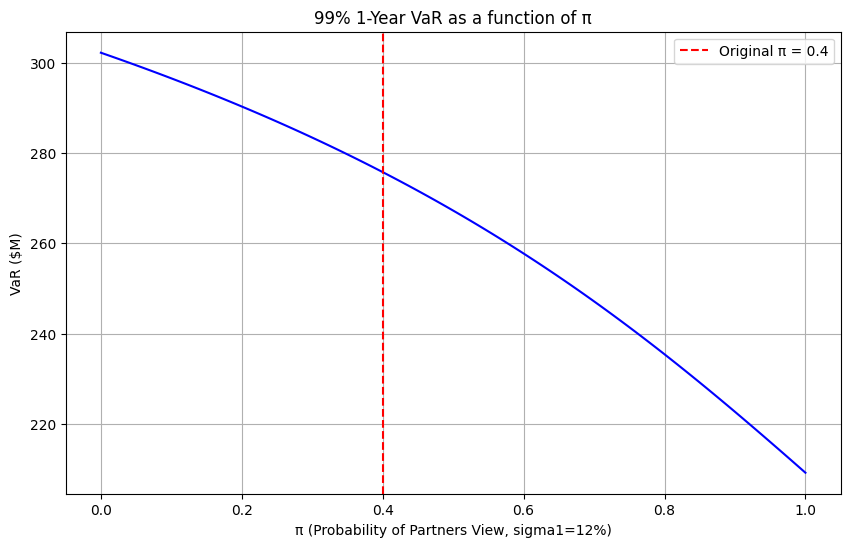

In [ ]:
import numpy as np
from scipy.stats import norm
from scipy.optimize import fsolve
import matplotlib.pyplot as plt

mu = 0.07
sigma1 = 0.12
sigma2 = 0.16
target_prob = 0.01
initial_investment = 1_000_000_000

def find_r_mix(pi_val, mu, sigma1, sigma2, target_prob):
    def equation(r_mix_val):
        return pi_val * norm.cdf((r_mix_val - mu) / sigma1) + \
               (1 - pi_val) * norm.cdf((r_mix_val - mu) / sigma2) - target_prob

    r_mix_initial_guess = -0.2758

    r_mix_solution = fsolve(equation, r_mix_initial_guess)[0]
    return r_mix_solution

def calculate_VaR_million(r_mix):
    return initial_investment * (-r_mix) / 1_000_000

pi_values = np.linspace(0, 1, 100)

VaR_values = []
for pi in pi_values:
    r_mix = find_r_mix(pi, mu, sigma1, sigma2, target_prob)
    VaR = calculate_VaR_million(r_mix)
    VaR_values.append(VaR)

plt.figure(figsize=(10, 6))
plt.plot(pi_values, VaR_values, linestyle='-', color='blue')
plt.title('99% 1-Year VaR as a function of π')
plt.xlabel('π (Probability of Partners View, sigma1=12%)')
plt.ylabel('VaR ($M)')
plt.grid(True)
plt.axvline(x=0.4, color='red', linestyle='--', label='Original π = 0.4')
plt.legend()
plt.show()

#### Comment on results:

As $\pi$ increases, the VaR generally decreases. This is because a higher $\pi$ means more weight is given to the distribution with lower volatility ($\sigma_1=12\%$). Lower volatility implies smaller potential losses at the 99% confidence level, hence a lower VaR.

The relationship between $\pi$ and VaR is non-linear. This is expected due to the nature of the mixture model and the properties of the cumulative distribution function (CDF) of the normal distribution.

When $\pi=0$, the entire weight is on my view (higher volatility $\sigma_2=16\%$), resulting in the highest VaR, which is approximately \$302.2M (from previous calculations).

When $\pi=1$, the entire weight is on my partner's view (lower volatility $\sigma_1=12\%$), resulting in the lowest VaR, approximately \$209.1M (from previous calculations).

The red dashed line marks the original $\pi=0.4$, showing that the VaR calculated in the previous question (approx. \$275.8M) falls on this curve. This indicates that as more weight shifts towards the higher volatility component (decreasing $\pi$), the overall tail risk (VaR) increases, and vice versa.

3. More challenging. After presenting your common view to your manager, you are challenged with an alternative view about volatility: $σ$ is time- varying. The volatility trader suggests that a sensible model for $σ$ is a gamma distribution. Explain in as many details as possible (either derive of formula or use a computer program) how to compute the VaR of your portfolio when returns have a normal distribution conditional on $σ$ and $σ$ is distributed according to a Gamma distribution.

#### Solution:

To compute the VaR under a stochastic volatility model where $\sigma$ follows a Gamma distribution, the most effective approach is Monte Carlo simulation. This computer program method works by generating the unconditional distribution of returns through a two-step process: for each simulation trial, first draw a random volatility $\sigma_i$ from the specified Gamma distribution. Next, using that specific $\sigma_i$, draw a random return $R_i$ from a Normal distribution conditioned on that volatility, $N(\mu, \sigma_i)$. Repeat this process a large number of times (say 100,000 iterations) to build a dataset of returns that accounts for the time-varying nature of the risk.

Once you have the population of simulated returns, you calculate the VaR empirically. Sort the simulated returns from lowest (worst loss) to highest. For a 99% confidence level, identify the return at the 1st percentile of this sorted list (e.g., the 1,000th worst value in a 100,000-trial simulation). The difference between your initial portfolio value ($W_0$) and the portfolio value at this percentile represents your Value-at-Risk. This method automatically captures the fat tails introduced by the mixture of volatilities without requiring you to derive a complex closed-form solution.